In [1]:
!pip install shap lime


In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('dataset.csv')

In [3]:
print('Dataset shape')
print(df.shape)

Dataset shape
(50000, 33)


In [4]:
df.columns

Index(['url_url', 'url_len_url', 'url_len_pre', 'url_len_suf',
       'url_len_params', 'url_len_query', 'url_len_fragment',
       'url_pre_entropy', 'url_suf_entropy', 'url_pre_https_count',
       'url_suf_https_count', 'url_pre_http_count', 'url_suf_http_count',
       'url_pre_count/', 'url_pre_count%', 'url_pre_count=', 'url_pre_count-',
       'url_pre_count@', 'url_pre_count.', 'url_suf_count/', 'url_suf_count%',
       'url_suf_count=', 'url_suf_count-', 'url_suf_count@', 'url_suf_count.',
       'url_pre_numbers_in_domain', 'url_suf_numbers_in_domain',
       'res_is_redirect', 'res_headers_type_num', 'res_constitute_url_num',
       'res_constitute_domain_type', 'res_state_code', 'label'],
      dtype='object')

In [5]:
print('\nFirst five rows')
print(df.head())


First five rows
                       url_url  url_len_url  url_len_pre  url_len_suf  \
0        https://psd2html.com/           21           20            1   
1     https://liutilities.com/           24           23            1   
2       http://www.gamedog.cn/           22           21            1   
3  https://www.pokerstars.com/           27           26            1   
4          https://pourmoi.jp/           19           18            1   

   url_len_params  url_len_query  url_len_fragment  url_pre_entropy  \
0               0              0                 0         3.584184   
1               0              0                 0         3.567040   
2               0              0                 0         3.784942   
3               0              0                 0         3.767183   
4               0              0                 0         3.572431   

   url_suf_entropy  url_pre_https_count  ...  url_suf_count@  url_suf_count.  \
0              0.0                   

In [6]:
print('\nDataset information')
print(df.info())


Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url_url                     50000 non-null  object 
 1   url_len_url                 50000 non-null  int64  
 2   url_len_pre                 50000 non-null  int64  
 3   url_len_suf                 50000 non-null  int64  
 4   url_len_params              50000 non-null  int64  
 5   url_len_query               50000 non-null  int64  
 6   url_len_fragment            50000 non-null  int64  
 7   url_pre_entropy             50000 non-null  float64
 8   url_suf_entropy             50000 non-null  float64
 9   url_pre_https_count         50000 non-null  int64  
 10  url_suf_https_count         50000 non-null  int64  
 11  url_pre_http_count          50000 non-null  int64  
 12  url_suf_http_count          50000 non-null  int64  
 13  url_pre_co

In [7]:
print('\nTarget distribution')
print(df['label'].value_counts())



Target distribution
label
0    25000
1    25000
Name: count, dtype: int64


In [8]:
if 'url_url' in df.columns:
    df = df.drop(columns=['url_url'])
    print('\nRemoved column: url_url')

print('\nFinal dataset shape after loading')
print(df.shape)


Removed column: url_url

Final dataset shape after loading
(50000, 32)


In [9]:
df.isnull().sum()

,0
url_len_url,0
url_len_pre,0
url_len_suf,0
url_len_params,0
url_len_query,0
url_len_fragment,0
url_pre_entropy,0
url_suf_entropy,0
url_pre_https_count,0
url_suf_https_count,0


In [10]:
from sklearn.model_selection import train_test_split

duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print('Dataset shape after duplicate removal:', df.shape)


Duplicate rows: 10914
Dataset shape after duplicate removal: (39086, 32)


In [11]:
X = df.drop(columns=['label'])
y = df['label']

print('\nFeature matrix shape:', X.shape)
print('Target vector shape :', y.shape)



Feature matrix shape: (39086, 31)
Target vector shape : (39086,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('\nTraining set')
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)

print('\nTesting set')
print('X_test :', X_test.shape)
print('y_test :', y_test.shape)




Training set
X_train: (31268, 31)
y_train: (31268,)

Testing set
X_test : (7818, 31)
y_test : (7818,)


In [13]:

print('\nTraining class distribution')
print(y_train.value_counts(normalize=True))

print('\nTesting class distribution')
print(y_test.value_counts(normalize=True))


Training class distribution
label
1    0.532429
0    0.467571
Name: proportion, dtype: float64

Testing class distribution
label
1    0.532361
0    0.467639
Name: proportion, dtype: float64


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Remove constant features

constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]

print('Constant columns found:', len(constant_cols))
print(constant_cols)

# Apply to both train and test
X_train = X_train.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)

print('\nShape after constant feature removal')
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)


Constant columns found: 4
['url_pre_count/', 'url_pre_count%', 'url_pre_count=', 'url_pre_count@']

Shape after constant feature removal
X_train: (31268, 27)
X_test : (7818, 27)


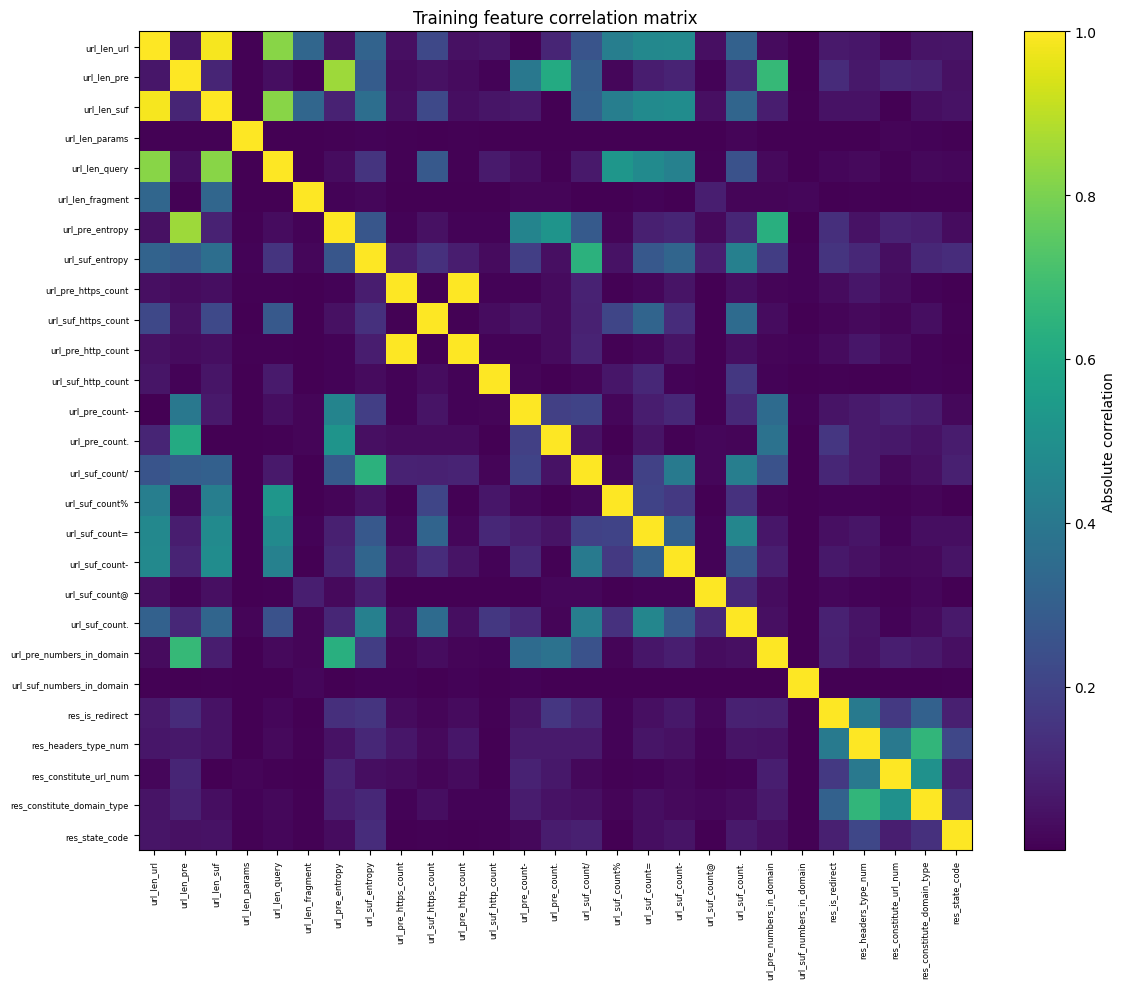

In [15]:
# Correlation analysis (training set only)

corr_matrix = X_train.corr().abs()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar(label='Absolute correlation')
plt.title('Training feature correlation matrix')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns, fontsize=6)
plt.tight_layout()
plt.show()


In [16]:
# Identify highly correlated feature
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

correlated_cols = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

print('\nHighly correlated columns:', len(correlated_cols))
print(correlated_cols)

# Remove correlated features

X_train = X_train.drop(columns=correlated_cols)
X_test = X_test.drop(columns=correlated_cols)

print('\nFinal feature shapes')
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

# Save preprocessing information


training_features = X_train.columns.tolist()

print('\nNumber of training features:', len(training_features))


Highly correlated columns: 2
['url_len_suf', 'url_pre_http_count']

Final feature shapes
X_train: (31268, 25)
X_test : (7818, 25)

Number of training features: 25


In [17]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline  # Import Pipeline
from sklearn.preprocessing import StandardScaler # Import StandardScaler
import pandas as pd


# Define models
cv_models = {
    "Logistic Regression (Scaled)": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric="logloss"
    )
}

# Stratified 5-fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in cv_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        "Precision": f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        "Recall": f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        "F1-score": f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        "ROC-AUC": f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}"
    })

cv_results_df = pd.DataFrame(cv_results)

print("===== Stratified 5-Fold Cross-Validation Results ====")
display(cv_results_df)

===== Stratified 5-Fold Cross-Validation Results ====


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression (Scaled),0.8370 ± 0.0059,0.8667 ± 0.0084,0.8201 ± 0.0075,0.8427 ± 0.0056,0.9138 ± 0.0031
1,Random Forest,0.9115 ± 0.0030,0.9327 ± 0.0028,0.8987 ± 0.0038,0.9154 ± 0.0029,0.9670 ± 0.0022
2,XGBoost,0.9225 ± 0.0033,0.9435 ± 0.0038,0.9089 ± 0.0032,0.9259 ± 0.0031,0.9751 ± 0.0016


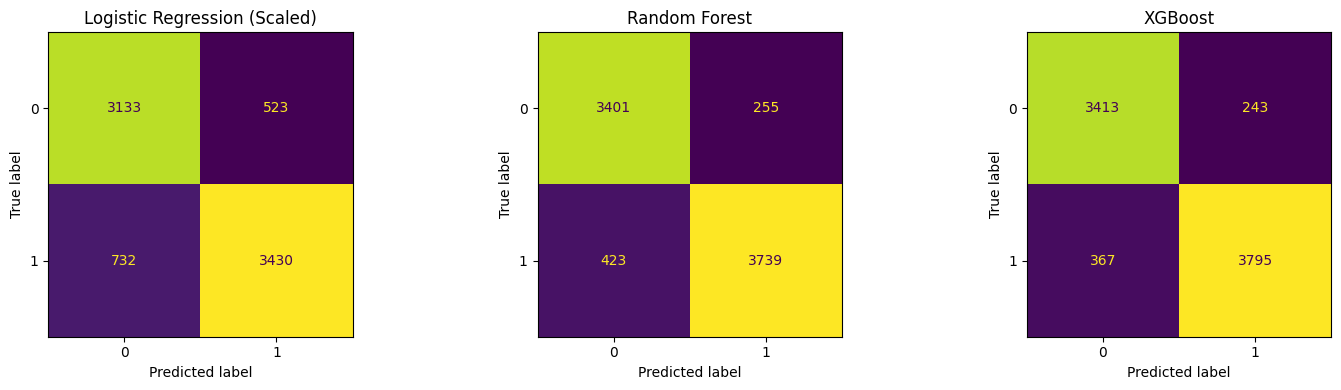

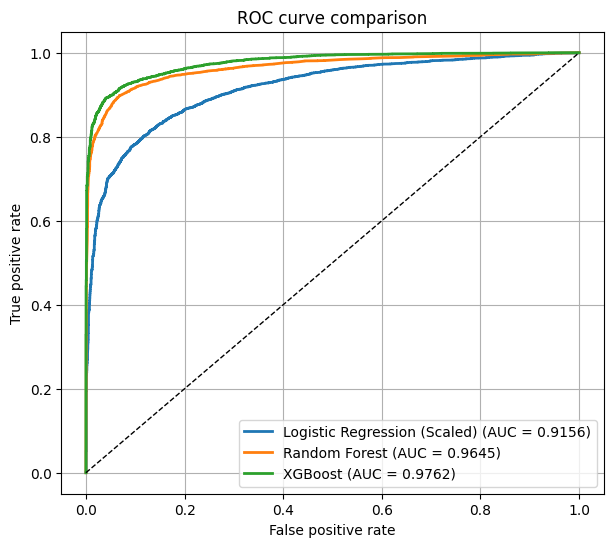

In [18]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# Dictionary to store fitted models and their predictions/probabilities on the test set
model_eval_results = {}

for name, model in cv_models.items():
    # Fit the model on the full training data
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Probability of the positive class

    # Calculate ROC AUC
    roc_auc = roc_auc_score(y_test, y_prob)

    model_eval_results[name] = {
        "y_pred": y_pred,
        "y_prob": y_prob,
        "roc_auc": roc_auc
    }


# ==========================
# Confusion Matrices
# ==========================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, model_eval_results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

# ==========================
# ROC curves
# ==========================

plt.figure(figsize=(7, 6))

for name, r in model_eval_results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {r['roc_auc']:.4f})"
    )

plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve comparison")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

===== Calibration Method Comparison =====


,Model,Brier Score,ECE,Log Loss
0,Uncalibrated,0.057378,0.008807,0.192070
1,Sigmoid,0.057447,0.023210,0.200473
2,Isotonic,0.055922,0.006719,0.187581


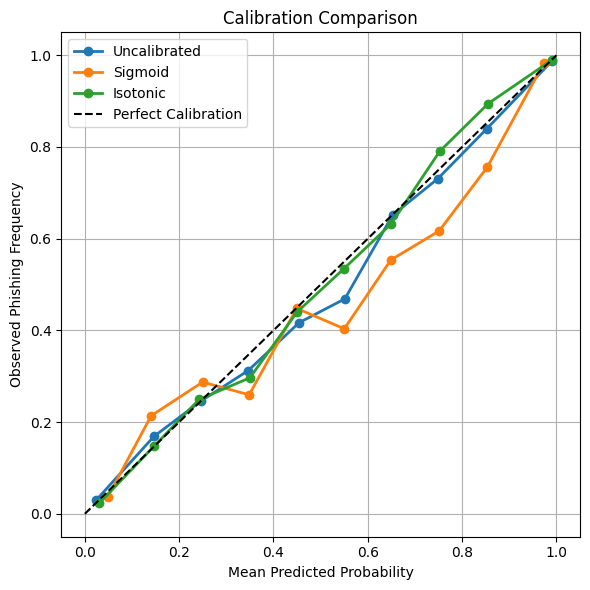

Saved: calibration_method_comparison.csv


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

# ==========================
# Train uncalibrated XGBoost
# ==========================

xgb_uncal = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric="logloss"
)

xgb_uncal.fit(X_train, y_train)
prob_uncal = xgb_uncal.predict_proba(X_test)[:, 1]

# ==========================
# Sigmoid calibration
# ==========================

xgb_sigmoid = CalibratedClassifierCV(
    estimator=XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric="logloss"
    ),
    method="sigmoid",
    cv=5
)

xgb_sigmoid.fit(X_train, y_train)
prob_sigmoid = xgb_sigmoid.predict_proba(X_test)[:, 1]

# ==========================
# Isotonic calibration
# ==========================

xgb_isotonic = CalibratedClassifierCV(
    estimator=XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric="logloss"
    ),
    method="isotonic",
    cv=5
)

xgb_isotonic.fit(X_train, y_train)
prob_isotonic = xgb_isotonic.predict_proba(X_test)[:, 1]

# ==========================
# ECE function
# ==========================

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    ece = 0.0

    for i in range(n_bins):
        mask = bin_ids == i

        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            weight = np.sum(mask) / len(y_true)

            ece += weight * abs(acc - conf)

    return ece

# ==========================
# Metrics
# ==========================

results = pd.DataFrame({
    "Model": [
        "Uncalibrated",
        "Sigmoid",
        "Isotonic"
    ],
    "Brier Score": [
        brier_score_loss(y_test, prob_uncal),
        brier_score_loss(y_test, prob_sigmoid),
        brier_score_loss(y_test, prob_isotonic)
    ],
    "ECE": [
        expected_calibration_error(y_test.values, prob_uncal),
        expected_calibration_error(y_test.values, prob_sigmoid),
        expected_calibration_error(y_test.values, prob_isotonic)
    ],
    "Log Loss": [
        log_loss(y_test, prob_uncal),
        log_loss(y_test, prob_sigmoid),
        log_loss(y_test, prob_isotonic)
    ]
})

print("===== Calibration Method Comparison =====")
display(results.round(6))

# ==========================
# Reliability diagram
# ==========================

plt.figure(figsize=(6,6))

for probs, label in [
    (prob_uncal, "Uncalibrated"),
    (prob_sigmoid, "Sigmoid"),
    (prob_isotonic, "Isotonic")
]:
    frac_pos, mean_pred = calibration_curve(
        y_test,
        probs,
        n_bins=10,
        strategy="uniform"
    )

    plt.plot(
        mean_pred,
        frac_pos,
        marker="o",
        linewidth=2,
        label=label
    )

plt.plot([0,1], [0,1], "k--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Phishing Frequency")
plt.title("Calibration Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("calibration.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

results.to_csv("calibration_method_comparison.csv", index=False)
print("Saved: calibration_method_comparison.csv")

In [20]:
import joblib

# Save the best performing model (calibrated XGBoost)
joblib.dump(xgb_isotonic, 'calibrated_xgboost_model.pkl')

print('Saved calibrated_xgboost_model.pkl')

Saved calibrated_xgboost_model.pkl


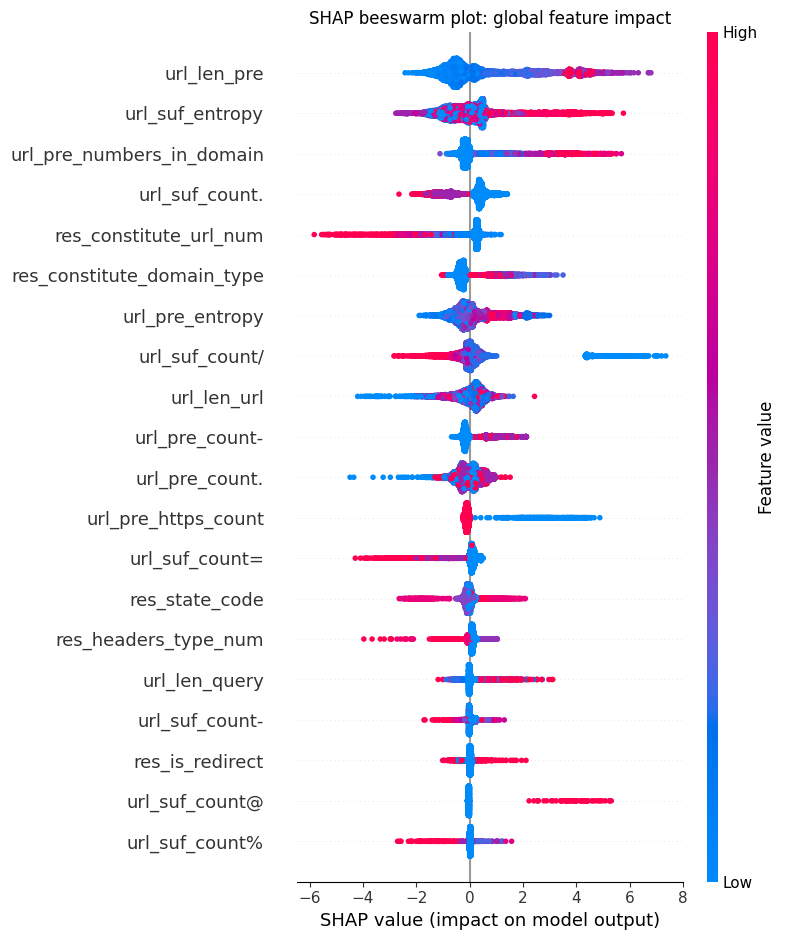

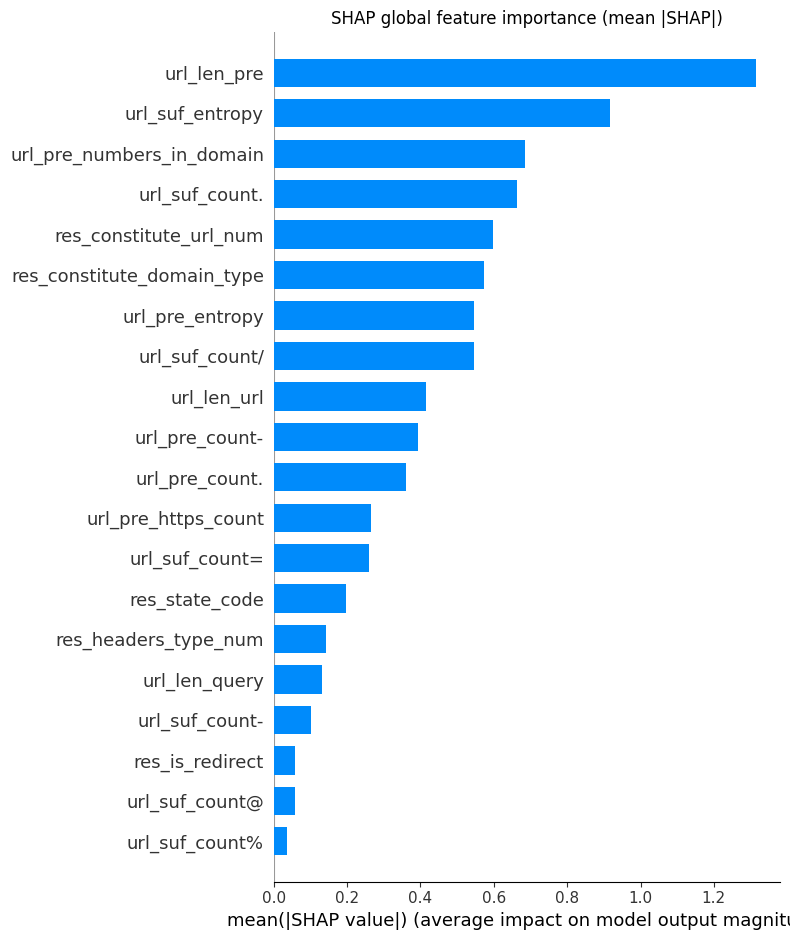

===== Top 20 Global SHAP Features =====


,Feature,Mean_Abs_SHAP
1,url_len_pre,1.314566
6,url_suf_entropy,0.917961
18,url_pre_numbers_in_domain,0.683998
17,url_suf_count.,0.663242
22,res_constitute_url_num,0.598063
23,res_constitute_domain_type,0.574225
5,url_pre_entropy,0.546321
12,url_suf_count/,0.544918
0,url_len_url,0.415190
10,url_pre_count-,0.392532


Saved: shap_global_feature_importance.csv


In [21]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================
# SHAP Global Explainability
# =====================================================

# Get the underlying XGBoost model from the calibrated model
base_model = xgb_isotonic.calibrated_classifiers_[0].estimator

# SHAP explainer
explainer = shap.TreeExplainer(base_model)

# Compute SHAP values on the test set
shap_values = explainer.shap_values(X_test)

# Handle binary classification output
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# =====================================================
# SHAP Beeswarm Plot
# =====================================================

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)
plt.title("SHAP beeswarm plot: global feature impact")
plt.tight_layout()
plt.savefig("SHAP beeswarm plot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()
# =====================================================
# SHAP Global Bar Plot
# =====================================================

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)
plt.title("SHAP global feature importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig("SHAP global feature.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# =====================================================
# Numerical feature importance table
# =====================================================

importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Abs_SHAP": abs(shap_values).mean(axis=0)
})

importance = importance.sort_values(
    by="Mean_Abs_SHAP",
    ascending=False
)

print("===== Top 20 Global SHAP Features =====")
display(importance.head(20))

importance.to_csv("shap_global_feature_importance.csv", index=False)
print("Saved: shap_global_feature_importance.csv")

In [22]:
import requests
import re
import math
import pandas as pd

from collections import Counter
from urllib.parse import urlparse


# =========================================================
# 1. ENTROPY
# =========================================================

def entropy(s):

    if not s:
        return 0.0

    counts = Counter(s)
    length = len(s)

    return -sum(
        (count / length) * math.log2(count / length)
        for count in counts.values()
    )


# =========================================================
# 2. HTTP RESPONSE FEATURES
# =========================================================

def extract_response_features(url):

    try:

        response = requests.get(
            url,
            timeout=5,
            allow_redirects=True,
            headers={"User-Agent": "Mozilla/5.0"}
        )

        # Redirect indicator
        res_is_redirect = int(len(response.history) > 0)

        # HTTP status code
        res_state_code = response.status_code

        # Number of response headers
        res_headers_type_num = len(response.headers)

        # HTML content
        html = response.text

        # Extract URLs from HTML
        urls = re.findall(
            r'https?://[^\s"<>]+',
            html
        )

        res_constitute_url_num = len(urls)

        # Extract unique domains
        domains = set()

        for u in urls:

            try:

                parsed_url = urlparse(u)

                if parsed_url.netloc:
                    domains.add(parsed_url.netloc)

            except Exception:
                pass

        res_constitute_domain_type = len(domains)

    except Exception:

        # Safe fallback when webpage cannot be accessed
        res_is_redirect = 0
        res_state_code = 0
        res_headers_type_num = 0
        res_constitute_url_num = 0
        res_constitute_domain_type = 0

    return {

        "res_is_redirect":
            res_is_redirect,

        "res_headers_type_num":
            res_headers_type_num,

        "res_constitute_url_num":
            res_constitute_url_num,

        "res_constitute_domain_type":
            res_constitute_domain_type,

        "res_state_code":
            res_state_code
    }


# =========================================================
# 3. URL FEATURE EXTRACTION
# =========================================================

def extract_features(url):

    parsed = urlparse(url)

    domain = parsed.netloc
    path = parsed.path
    query = parsed.query
    fragment = parsed.fragment

    url_features = {

        "url_len_url":
            len(url),

        "url_len_pre":
            len(domain),

        "url_len_suf":
            len(path),

        "url_len_params":
            len(query),

        "url_len_query":
            len(query),

        "url_len_fragment":
            len(fragment),

        "url_pre_entropy":
            entropy(domain),

        "url_suf_entropy":
            entropy(path + query),

        "url_pre_https_count":
            domain.count("https"),

        "url_suf_https_count":
            (path + query).count("https"),

        "url_pre_http_count":
            domain.count("http"),

        "url_suf_http_count":
            (path + query).count("http"),

        "url_pre_count/":
            domain.count("/"),

        "url_suf_count/":
            path.count("/"),

        "url_pre_count%":
            domain.count("%"),

        "url_suf_count%":
            path.count("%"),

        "url_pre_count=":
            domain.count("="),

        "url_suf_count=":
            query.count("="),

        "url_pre_count-":
            domain.count("-"),

        "url_suf_count-":
            path.count("-"),

        "url_pre_count@":
            domain.count("@"),

        "url_suf_count@":
            path.count("@"),

        "url_pre_count.":
            domain.count("."),

        "url_suf_count.":
            path.count("."),

        "url_pre_numbers_in_domain":
            sum(c.isdigit() for c in domain),

        "url_suf_numbers_in_domain":
            sum(c.isdigit() for c in path)
    }

    # HTTP response features
    response_features = extract_response_features(url)

    return {
        **url_features,
        **response_features
    }


# =========================================================
# 4. PREPARE USER URL
# =========================================================

def prepare_user_url(
    url,
    training_features
):

    # Remove accidental spaces
    url = url.strip()

    # Add HTTPS if scheme is missing
    if not url.startswith(("http://", "https://")):
        url = "https://" + url

    # Extract features
    features = extract_features(url)

    # Convert to DataFrame
    X_input = pd.DataFrame([features])

    # =====================================================
    # SAME FEATURES REMOVED DURING TRAINING
    # =====================================================

    remove_cols = [

        "url_len_suf",

        "url_pre_http_count",

        "url_pre_count/",

        "url_pre_count%",

        "url_pre_count=",

        "url_pre_count@"
    ]

    X_input = X_input.drop(
        columns=remove_cols,
        errors="ignore"
    )

    # =====================================================
    # CHECK FEATURE CONSISTENCY
    # =====================================================

    missing_features = [
        col
        for col in training_features
        if col not in X_input.columns
    ]

    extra_features = [
        col
        for col in X_input.columns
        if col not in training_features
    ]

    # =====================================================
    # EXACT TRAINING FEATURE ORDER
    # =====================================================

    X_input = X_input.reindex(
        columns=training_features,
        fill_value=0
    )

    return (
        url,
        X_input,
        missing_features,
        extra_features
    )


# =========================================================
# 5. FINAL EXPLAINPHISH PREDICTION
# =========================================================

def predict_url(
    url,
    base_model,
    calibrated_model,
    training_features,
    model_name="XGBoost + Isotonic Calibration"
):

    print("\n" + "=" * 70)
    print("ExplainPhish - Phishing URL Detection")
    print("=" * 70)

    # =====================================================
    # PREPARE USER URL
    # =====================================================

    (
        url,
        X_input,
        missing_features,
        extra_features
    ) = prepare_user_url(
        url,
        training_features
    )

    print(f"Model              : {model_name}")
    print(f"URL                : {url}")

    # =====================================================
    # FEATURE CONSISTENCY CHECK
    # =====================================================

    if missing_features:

        print("\nWarning: Missing training features:")
        print(missing_features)

    if extra_features:

        print("\nWarning: Extra extracted features:")
        print(extra_features)

    # =====================================================
    # RAW / UNCALIBRATED XGBOOST PROBABILITY
    # =====================================================

    raw_prob = base_model.predict_proba(
        X_input
    )[0]

    raw_legitimate = float(
        raw_prob[0]
    )

    raw_phishing = float(
        raw_prob[1]
    )

    # =====================================================
    # ISOTONIC CALIBRATED PROBABILITY
    # =====================================================

    calibrated_prob = calibrated_model.predict_proba(
        X_input
    )[0]

    calibrated_legitimate = float(
        calibrated_prob[0]
    )

    calibrated_phishing = float(
        calibrated_prob[1]
    )

    # =====================================================
    # FINAL PREDICTION
    #
    # IMPORTANT:
    # FINAL DECISION USES CALIBRATED PROBABILITY
    # =====================================================

    prediction = int(
        calibrated_phishing >= 0.5
    )

    label = (
        "PHISHING"
        if prediction == 1
        else "LEGITIMATE"
    )

    # =====================================================
    # CONFIDENCE
    #
    # Based on calibrated probability
    # =====================================================

    confidence_score = max(
        calibrated_legitimate,
        calibrated_phishing
    ) * 100

    if confidence_score >= 85:

        confidence = "High"

    elif confidence_score >= 60:

        confidence = "Medium"

    else:

        confidence = "Low"

    # =====================================================
    # RISK LEVEL
    #
    # Based on calibrated phishing probability
    # =====================================================

    if calibrated_phishing < 0.30:

        risk_level = "Low Risk"

    elif calibrated_phishing < 0.70:

        risk_level = "Medium Risk"

    else:

        risk_level = "High Risk"

    # =====================================================
    # DISPLAY RAW PROBABILITY
    # =====================================================

    print("\nUncalibrated XGBoost Probability")

    print(
        f"Legitimate         : "
        f"{raw_legitimate:.4f}"
    )

    print(
        f"Phishing           : "
        f"{raw_phishing:.4f}"
    )

    # =====================================================
    # DISPLAY CALIBRATED PROBABILITY
    # =====================================================

    print("\nCalibrated Probability (Isotonic)")

    print(
        f"Legitimate         : "
        f"{calibrated_legitimate:.4f}"
    )

    print(
        f"Phishing           : "
        f"{calibrated_phishing:.4f}"
    )

    # =====================================================
    # FINAL PREDICTION
    # =====================================================

    print("\nFinal Prediction")

    print(
        f"Prediction         : "
        f"{label}"
    )

    # =====================================================
    # CONFIDENCE
    # =====================================================

    print("\nConfidence")

    print(
        f"Confidence Score   : "
        f"{confidence_score:.2f}% ({confidence})"
    )

    # =====================================================
    # RISK
    # =====================================================

    print("\nRisk Assessment")

    print(
        f"Risk Level         : "
        f"{risk_level}"
    )

    print("=" * 70)

    # =====================================================
    # RETURN ALL RESULTS
    # =====================================================

    return {

        "url": url,

        "X_input": X_input,

        "prediction": prediction,

        "label": label,

        # -----------------------------
        # Raw XGBoost probability
        # -----------------------------

        "raw_probability":
            raw_prob,

        "raw_legitimate_probability":
            raw_legitimate,

        "raw_phishing_probability":
            raw_phishing,

        # -----------------------------
        # Isotonic calibrated probability
        # -----------------------------

        "calibrated_probability":
            calibrated_prob,

        "calibrated_legitimate_probability":
            calibrated_legitimate,

        "calibrated_phishing_probability":
            calibrated_phishing,

        # -----------------------------
        # Confidence
        # -----------------------------

        "confidence_score":
            confidence_score,

        "confidence":
            confidence,

        # -----------------------------
        # Risk
        # -----------------------------

        "risk_level":
            risk_level,

        # -----------------------------
        # Feature consistency
        # -----------------------------

        "missing_features":
            missing_features,

        "extra_features":
            extra_features
    }


# =========================================================
# 6. USER INPUT
# =========================================================

url = input("Enter a URL: ")


# =========================================================
# 7. RUN EXPLAINPHISH
# =========================================================

result = predict_url(

    url=url,

    # Original XGBoost model
    base_model=xgb_uncal,

    # Best calibration model according
    # to your current results
    calibrated_model=xgb_isotonic,

    # Exact training feature order
    training_features=X_train.columns,

    model_name="XGBoost + Isotonic Calibration"
)

Enter a URL: https://www.ajio.com/?utm_source=prodigiousonline&utm_medium=affiliate&utm_campaign=pass_your_subid(utm_campaignvalue)&utm_term=passutm_term&clickid=6a7aee562a057f0001a14261&pid=86&offer_id=2&attribution_window=1D&return_cancellation_window=45D&gad_source=1

ExplainPhish - Phishing URL Detection
Model              : XGBoost + Isotonic Calibration
URL                : https://www.ajio.com/?utm_source=prodigiousonline&utm_medium=affiliate&utm_campaign=pass_your_subid(utm_campaignvalue)&utm_term=passutm_term&clickid=6a7aee562a057f0001a14261&pid=86&offer_id=2&attribution_window=1D&return_cancellation_window=45D&gad_source=1

Uncalibrated XGBoost Probability
Legitimate         : 0.6287
Phishing           : 0.3713

Calibrated Probability (Isotonic)
Legitimate         : 0.8409
Phishing           : 0.1591

Final Prediction
Prediction         : LEGITIMATE

Confidence
Confidence Score   : 84.09% (Medium)

Risk Assessment
Risk Level         : Low Risk



Local SHAP Explanation


,Feature,Feature Value,SHAP Value,Prediction,SHAP Explanation
14,url_suf_count=,10.0,-3.110324,LEGITIMATE,-3.11032 → LEGITIMATE
21,res_headers_type_num,13.0,-2.265599,LEGITIMATE,-2.26560 → LEGITIMATE
3,url_len_query,235.0,1.898322,PHISHING,+1.89832 → PHISHING
1,url_len_pre,12.0,0.877563,PHISHING,+0.87756 → PHISHING
11,url_pre_count.,2.0,-0.835686,LEGITIMATE,-0.83569 → LEGITIMATE
17,url_suf_count.,0.0,0.789875,PHISHING,+0.78988 → PHISHING
22,res_constitute_url_num,0.0,0.515375,PHISHING,+0.51537 → PHISHING
24,res_state_code,403.0,-0.372201,LEGITIMATE,-0.37220 → LEGITIMATE
23,res_constitute_domain_type,0.0,-0.310865,LEGITIMATE,-0.31086 → LEGITIMATE
10,url_pre_count-,0.0,-0.151281,LEGITIMATE,-0.15128 → LEGITIMATE



SHAP waterfall plot saved as: SHAP_waterfall_plot.png


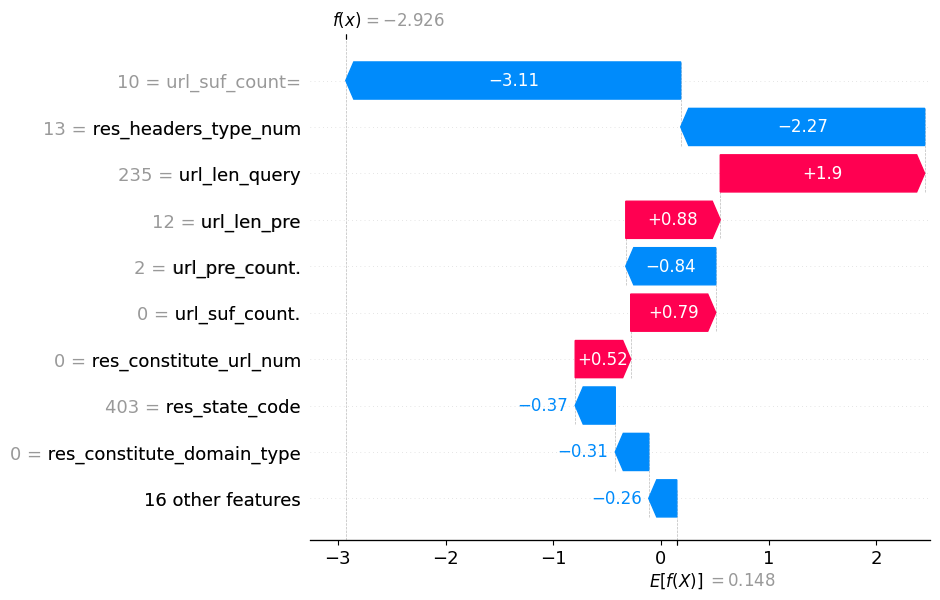

In [26]:
import shap
import matplotlib.pyplot as plt
import pandas as pd


# =====================================================
# Local SHAP explanation for user-entered URL
# =====================================================

def explain_url_shap_local(
    result,
    calibrated_model,
    top_n=10,
    min_shap=0.1
):

    # -------------------------------------------------
    # Processed feature vector
    # -------------------------------------------------

    X_input = result["X_input"]

    # -------------------------------------------------
    # Underlying XGBoost model
    # -------------------------------------------------

    base_model = calibrated_model.calibrated_classifiers_[0].estimator

    # -------------------------------------------------
    # SHAP explainer
    # -------------------------------------------------

    explainer = shap.TreeExplainer(base_model)

    # -------------------------------------------------
    # Calculate SHAP values
    # -------------------------------------------------

    shap_values = explainer.shap_values(X_input)

    # Handle binary classification output
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap_values = shap_values.flatten()

    # -------------------------------------------------
    # Create SHAP importance table
    # -------------------------------------------------

    local_importance = pd.DataFrame({

        "Feature": X_input.columns,

        "Feature Value": X_input.iloc[0].values,

        "SHAP Value": shap_values
    })

    # -------------------------------------------------
    # Absolute SHAP value
    # -------------------------------------------------

    local_importance["Abs_SHAP"] = (
        local_importance["SHAP Value"].abs()
    )

    # -------------------------------------------------
    # Prediction direction
    #
    # Positive SHAP -> PHISHING
    # Negative SHAP -> LEGITIMATE
    # -------------------------------------------------

    local_importance["Prediction"] = (
        local_importance["SHAP Value"]
        .apply(
            lambda x:
            "PHISHING"
            if x > 0
            else "LEGITIMATE"
        )
    )

    # -------------------------------------------------
    # SHAP explanation text
    # -------------------------------------------------

    local_importance["SHAP Explanation"] = (
        local_importance["SHAP Value"]
        .apply(
            lambda x:
            f"{x:+.5f} → "
            + (
                "PHISHING"
                if x > 0
                else "LEGITIMATE"
            )
        )
    )

    # -------------------------------------------------
    # Sort by SHAP importance
    # -------------------------------------------------

    local_importance = local_importance.sort_values(
        by="Abs_SHAP",
        ascending=False
    )

    # -------------------------------------------------
    # Keep only relevant features
    # -------------------------------------------------

    relevant_features = local_importance[
        local_importance["Abs_SHAP"] >= min_shap
    ].head(top_n).copy()

    # -------------------------------------------------
    # Display local SHAP explanation
    # -------------------------------------------------

    print("\n" + "=" * 80)
    print("Local SHAP Explanation")
    print("=" * 80)

    if len(relevant_features) == 0:

        print(
            f"No features found with "
            f"|SHAP| >= {min_shap}"
        )

    else:

        display(
            relevant_features[
                [
                    "Feature",
                    "Feature Value",
                    "SHAP Value",
                    "Prediction",
                    "SHAP Explanation"
                ]
            ]
        )

    # =================================================
    # SHAP Waterfall Plot
    # =================================================

    try:

        # -------------------------------------------------
        # Handle expected value
        # -------------------------------------------------

        expected_value = explainer.expected_value

        if hasattr(expected_value, "__len__"):

            if len(expected_value) > 1:
                expected_value = expected_value[1]
            else:
                expected_value = expected_value[0]

        # -------------------------------------------------
        # Create SHAP Explanation
        # -------------------------------------------------

        explanation = shap.Explanation(

            values=shap_values,

            base_values=expected_value,

            data=X_input.iloc[0].values,

            feature_names=X_input.columns
        )

        # -------------------------------------------------
        # Create Waterfall Plot
        # IMPORTANT: show=False
        # -------------------------------------------------

        shap.plots.waterfall(
            explanation,
            max_display=top_n,
            show=False
        )

        # -------------------------------------------------
        # Get current figure
        # -------------------------------------------------

        fig = plt.gcf()

        # -------------------------------------------------
        # Save waterfall plot
        # -------------------------------------------------

        fig.savefig(
            "SHAP_waterfall_plot.png",
            dpi=300,
            bbox_inches="tight"
        )

        print(
            "\nSHAP waterfall plot saved as:"
            " SHAP_waterfall_plot.png"
        )

        # -------------------------------------------------
        # Display waterfall plot
        # -------------------------------------------------

        plt.show()

        # -------------------------------------------------
        # Close figure
        # -------------------------------------------------

        plt.close(fig)

    except Exception as e:

        print(
            "Waterfall plot could not be generated:",
            e
        )

    # -------------------------------------------------
    # Return relevant features
    # -------------------------------------------------

    return relevant_features


# =====================================================
# Generate Local SHAP Explanation
# =====================================================

local_shap = explain_url_shap_local(

    result=result,

    calibrated_model=xgb_isotonic,

    top_n=10,

    min_shap=0.1
)

\n======================================================================
LIME Local Explanation


,Feature,LIME Weight,Abs_Weight
0,url_len_params > 0.00,-0.334787,0.334787
1,res_headers_type_num > 11.00,-0.158383,0.158383
2,url_suf_count/ <= 1.00,0.134452,0.134452
3,url_suf_http_count <= 0.00,-0.092050,0.092050
4,res_constitute_url_num <= 0.00,0.079549,0.079549
5,res_constitute_domain_type <= 0.00,-0.058469,0.058469
6,url_suf_count. <= 0.00,0.051145,0.051145
7,url_pre_numbers_in_domain <= 0.00,-0.045816,0.045816
8,url_len_pre <= 21.00,-0.038368,0.038368
9,url_suf_numbers_in_domain <= 0.00,0.010676,0.010676


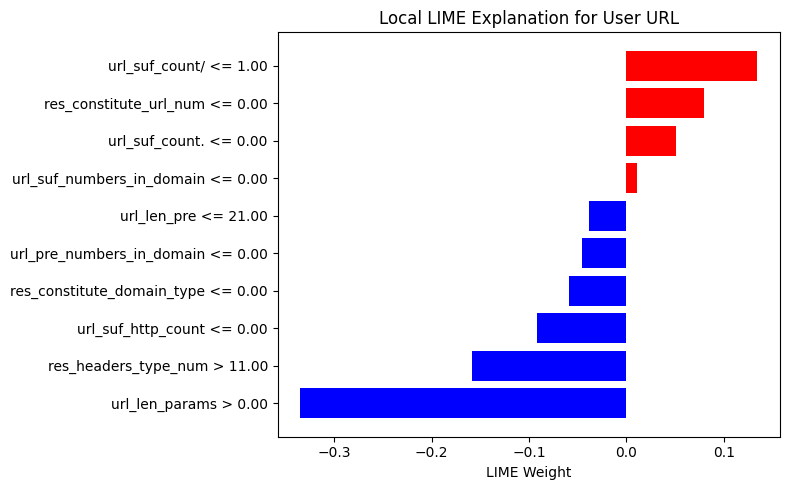

In [24]:
from lime.lime_tabular import LimeTabularExplainer
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# LIME explainer (initialize once)
# =====================================================

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Legitimate", "Phishing"],
    mode="classification"
)

# =====================================================
# Local LIME explanation for user-entered URL
# =====================================================

def explain_url_lime_local(result, calibrated_model, top_n=10):

    X_input = result["X_input"]

    # Use calibrated model for explanation
    explanation = lime_explainer.explain_instance(
        X_input.iloc[0].values,
        calibrated_model.predict_proba,
        num_features=top_n
    )

    # Convert explanation to DataFrame
    lime_df = pd.DataFrame(
        explanation.as_list(),
        columns=["Feature", "LIME Weight"]
    )

    lime_df["Abs_Weight"] = lime_df["LIME Weight"].abs()
    lime_df = lime_df.sort_values(
        by="Abs_Weight",
        ascending=False
    )

    print("\\n" + "=" * 70)
    print("LIME Local Explanation")
    print("=" * 70)
    display(lime_df)

    # -------------------------------------------------
    # LIME bar plot
    # -------------------------------------------------

    plt.figure(figsize=(8, 5))

    plot_df = lime_df.sort_values("LIME Weight")

    colors = [
        "red" if x > 0 else "blue"
        for x in plot_df["LIME Weight"]
    ]

    plt.barh(
        plot_df["Feature"],
        plot_df["LIME Weight"],
        color=colors
    )

    plt.xlabel("LIME Weight")
    plt.title("Local LIME Explanation for User URL")
    plt.tight_layout()
    plt.show()

    return lime_df

# =====================================================
# Generate LIME explanation
# =====================================================

lime_values = explain_url_lime_local(
    result=result,
    calibrated_model=xgb_isotonic,
    top_n=10
)


3. SHAP DEPENDENCE PLOTS

Generating dependence plots for:
 - url_len_pre
 - url_suf_entropy
 - url_pre_numbers_in_domain
 - url_suf_count.
 - res_constitute_url_num

Generating dependence plot for: url_len_pre


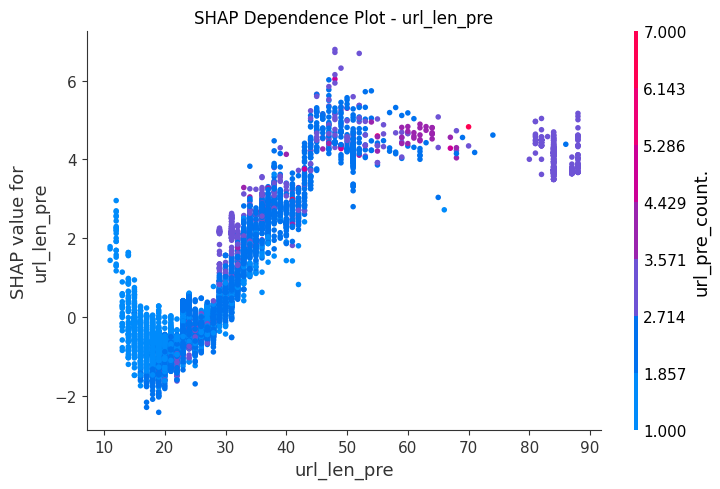


Generating dependence plot for: url_suf_entropy


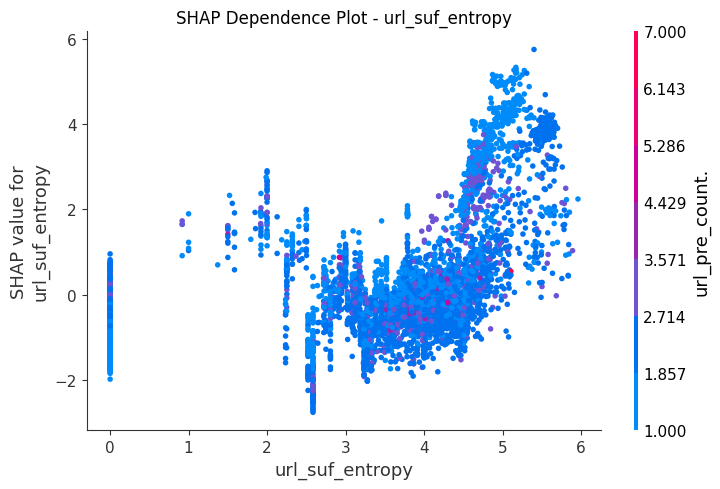


Generating dependence plot for: url_pre_numbers_in_domain


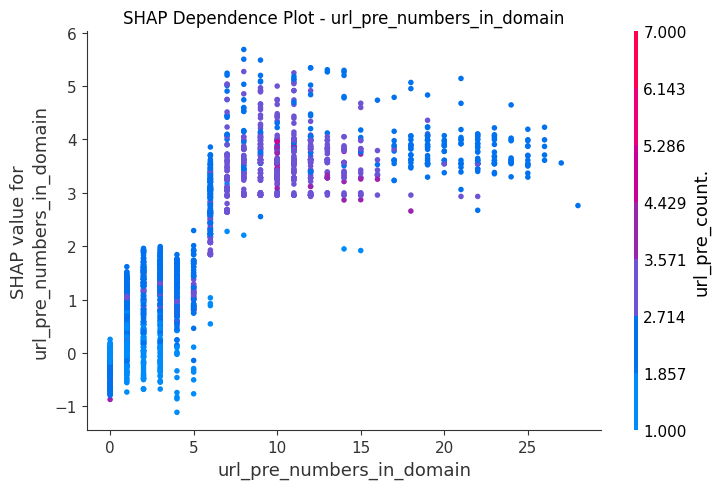


Generating dependence plot for: url_suf_count.


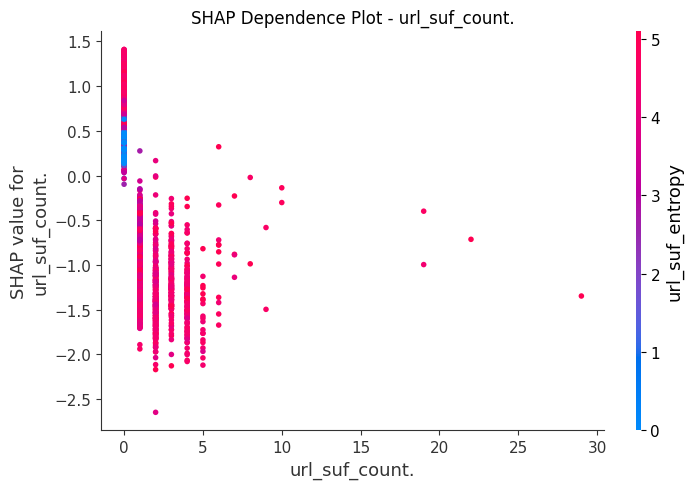


Generating dependence plot for: res_constitute_url_num


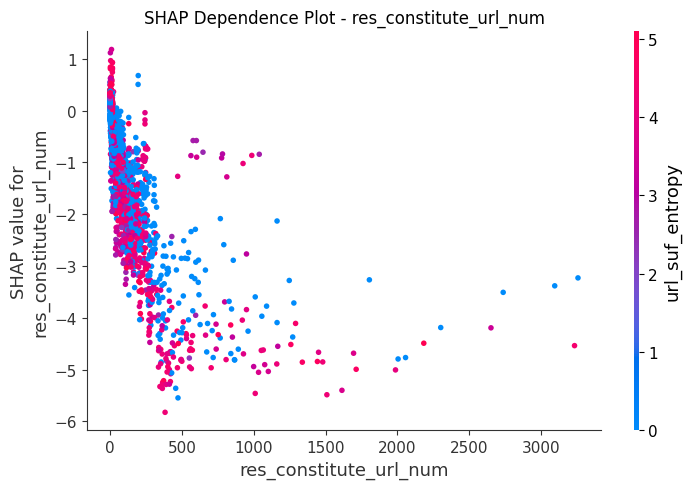

In [29]:

# ============================================================
# DEPENDENCE PLOTS
# ============================================================

print("\n" + "=" * 70)
print("3. SHAP DEPENDENCE PLOTS")
print("=" * 70)


# ------------------------------------------------------------
# 10. GET TOP FEATURES
# ------------------------------------------------------------

top_features = (
    importance
    .head(5)["Feature"]
    .tolist()
)

print("\nGenerating dependence plots for:")

for feature in top_features:
    print(" -", feature)


# ------------------------------------------------------------
# 11. DEPENDENCE PLOT FOR EACH TOP FEATURE
# ------------------------------------------------------------

for feature in top_features:

    print(
        f"\nGenerating dependence plot for: {feature}"
    )

    shap.dependence_plot(
        feature,
        shap_values,
        X_test,
        interaction_index="auto",
        show=False
    )

    plt.title(
        f"SHAP Dependence Plot - {feature}"
    )

    plt.tight_layout()

    plt.savefig("dependence.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

In [35]:
# =====================================================
# LIME LOCAL EXPLANATION
# =====================================================

from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt


print("\n" + "="*60)
print("LIME LOCAL EXPLANATION - USER URL")
print("="*60)


# =====================================================
# Create LIME explainer
# =====================================================

lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=[
        "Legitimate",
        "Phishing"
    ],
    mode="classification",
    random_state=42
)


# =====================================================
# Generate LIME explanation
# =====================================================

lime_explanation = lime_explainer.explain_instance(
    result["X_input"].iloc[0].values,
    xgb_isotonic.predict_proba,
    num_features=10
)


# =====================================================
# Display LIME features
# =====================================================

lime_result = lime_explanation.as_list()


print("\nTop LIME Features:")

for feature, weight in lime_result:

    print(
        feature,
        ":",
        round(weight, 5)
    )


# =====================================================
# LIME VISUALIZATION
# =====================================================

lime_explanation.show_in_notebook()

plt.show()




LIME LOCAL EXPLANATION - USER URL

Top LIME Features:
url_len_params > 0.00 : -0.32973
res_headers_type_num > 11.00 : -0.14587
url_suf_count/ <= 1.00 : 0.13824
res_constitute_url_num <= 0.00 : 0.09882
res_constitute_domain_type <= 0.00 : -0.06299
url_pre_numbers_in_domain <= 0.00 : -0.04626
url_suf_count% <= 0.00 : 0.04294
url_suf_count= > 0.00 : -0.04084
url_suf_numbers_in_domain <= 0.00 : 0.03624
url_suf_http_count <= 0.00 : -0.02153



LIME graph saved as: lime.png


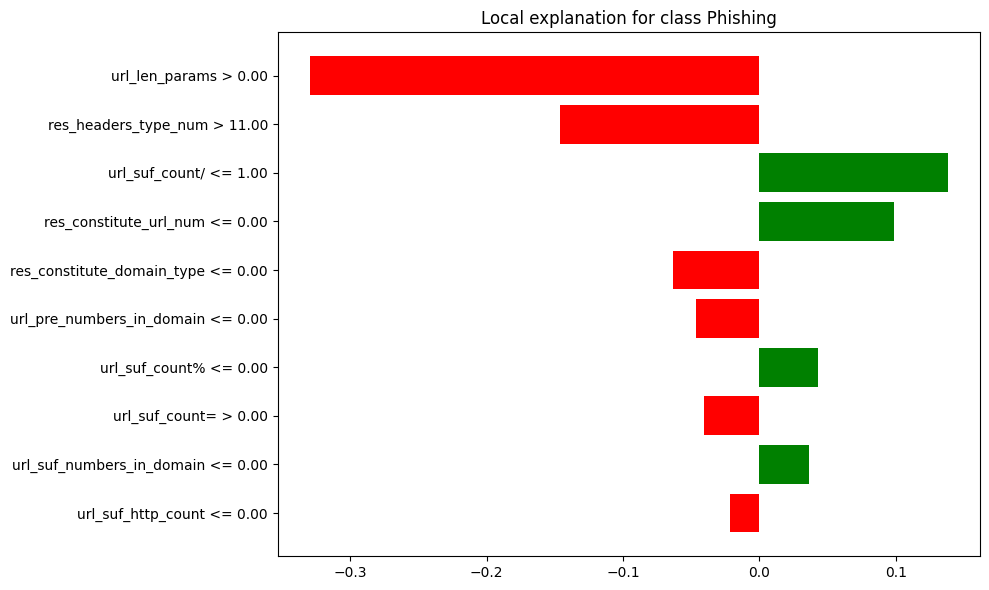

In [37]:
# =====================================================
# LIME GRAPH
# =====================================================

fig = lime_explanation.as_pyplot_figure(
    label=1
)

fig.set_size_inches(10, 6)

fig.tight_layout()


# =====================================================
# SAVE LIME GRAPH
# =====================================================

fig.savefig(
    "lime.png",
    dpi=300,
    bbox_inches="tight"
)

print("\nLIME graph saved as: lime.png")


# =====================================================
# DISPLAY LIME GRAPH
# =====================================================

plt.show()

plt.close(fig)

\n======================================================================
SHAP-LIME Agreement Analysis (User URL)
Top-10 Feature Overlap : 0.500
Spearman Correlation       : 0.259
Cosine Similarity          : 0.218
Sign Agreement             : 0.267
\nTop Feature Comparison


,Feature,SHAP,LIME,Abs_SHAP,Abs_LIME
12,url_suf_count=,-3.110324,0.000000,3.110324,0.000000
2,res_headers_type_num,-2.265599,-0.158383,2.265599,0.158383
6,url_len_query,1.898322,0.000000,1.898322,0.000000
5,url_len_pre,0.877563,-0.038368,0.877563,0.038368
8,url_pre_count.,-0.835686,0.000000,0.835686,0.000000
10,url_suf_count.,0.789875,0.051145,0.789875,0.051145
1,res_constitute_url_num,0.515375,0.079549,0.515375,0.079549
3,res_state_code,-0.372201,0.000000,0.372201,0.000000
0,res_constitute_domain_type,-0.310865,-0.058469,0.310865,0.058469
7,url_pre_count-,-0.151281,0.000000,0.151281,0.000000


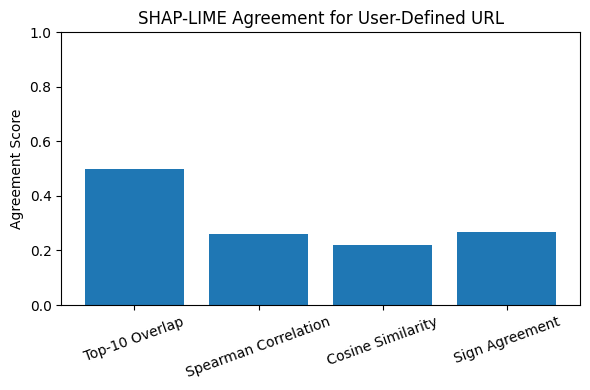

\nAgreement Summary


,Metric,Value
0,Top-10 Overlap,0.500000
1,Spearman Correlation,0.259259
2,Cosine Similarity,0.218462
3,Sign Agreement,0.266667


In [38]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# =====================================================
# SHAP-LIME agreement for the same user-defined URL
# =====================================================

def shap_lime_agreement(local_shap, lime_values, top_k=10):

    # -----------------------------
    # Prepare SHAP values
    # -----------------------------
    shap_df = local_shap[["Feature", "SHAP Value"]].copy()
    shap_df.columns = ["Feature", "SHAP"]

    # -----------------------------
    # Prepare LIME values
    # -----------------------------
    lime_df = lime_values[["Feature", "LIME Weight"]].copy()
    lime_df.columns = ["Feature", "LIME"]

    # Clean LIME feature names
    cleaned = []
    for f in lime_df["Feature"]:
        if "<=" in f:
            cleaned.append(f.split("<=")[0].strip())
        elif ">" in f:
            cleaned.append(f.split(">")[0].strip())
        elif "<" in f:
            cleaned.append(f.split("<")[0].strip())
        elif "=" in f:
            cleaned.append(f.split("=")[0].strip())
        else:
            cleaned.append(f.strip())

    lime_df["Feature"] = cleaned

    # -----------------------------
    # Merge SHAP and LIME
    # -----------------------------
    comparison = pd.merge(
        shap_df,
        lime_df,
        on="Feature",
        how="outer"
    ).fillna(0)

    comparison["Abs_SHAP"] = comparison["SHAP"].abs()
    comparison["Abs_LIME"] = comparison["LIME"].abs()

    # -----------------------------
    # Top-k overlap
    # -----------------------------
    shap_top = set(
        comparison.nlargest(top_k, "Abs_SHAP")["Feature"]
    )

    lime_top = set(
        comparison.nlargest(top_k, "Abs_LIME")["Feature"]
    )

    overlap = len(shap_top & lime_top) / top_k

    # -----------------------------
    # Spearman correlation
    # -----------------------------
    spearman_corr, _ = spearmanr(
        comparison["SHAP"],
        comparison["LIME"]
    )

    if np.isnan(spearman_corr):
        spearman_corr = 0.0

    # -----------------------------
    # Cosine similarity
    # -----------------------------
    cosine = cosine_similarity(
        comparison["SHAP"].values.reshape(1, -1),
        comparison["LIME"].values.reshape(1, -1)
    )[0, 0]

    # -----------------------------
    # Sign agreement
    # -----------------------------
    sign = np.mean(
        np.sign(comparison["SHAP"]) ==
        np.sign(comparison["LIME"])
    )

    # -----------------------------
    # Print results
    # -----------------------------
    print("\\n" + "=" * 70)
    print("SHAP-LIME Agreement Analysis (User URL)")
    print("=" * 70)

    print(f"Top-{top_k} Feature Overlap : {overlap:.3f}")
    print(f"Spearman Correlation       : {spearman_corr:.3f}")
    print(f"Cosine Similarity          : {cosine:.3f}")
    print(f"Sign Agreement             : {sign:.3f}")

    # -----------------------------
    # Comparison table
    # -----------------------------
    comparison = comparison.sort_values(
        by="Abs_SHAP",
        ascending=False
    )

    print("\\nTop Feature Comparison")
    display(comparison.head(10))

    # -----------------------------
    # Agreement summary
    # -----------------------------
    summary = pd.DataFrame({
        "Metric": [
            f"Top-{top_k} Overlap",
            "Spearman Correlation",
            "Cosine Similarity",
            "Sign Agreement"
        ],
        "Value": [
            overlap,
            spearman_corr,
            cosine,
            sign
        ]
    })

    # -----------------------------
    # Bar chart of agreement metrics
    # -----------------------------
    plt.figure(figsize=(6,4))
    plt.bar(summary["Metric"], summary["Value"])
    plt.ylim(0, 1)
    plt.ylabel("Agreement Score")
    plt.title("SHAP-LIME Agreement for User-Defined URL")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    return summary, comparison

# =====================================================
# Run agreement analysis
# =====================================================

agreement_summary, feature_comparison = shap_lime_agreement(
    local_shap=local_shap,
    lime_values=lime_values,
    top_k=10
)

print("\\nAgreement Summary")
display(agreement_summary)

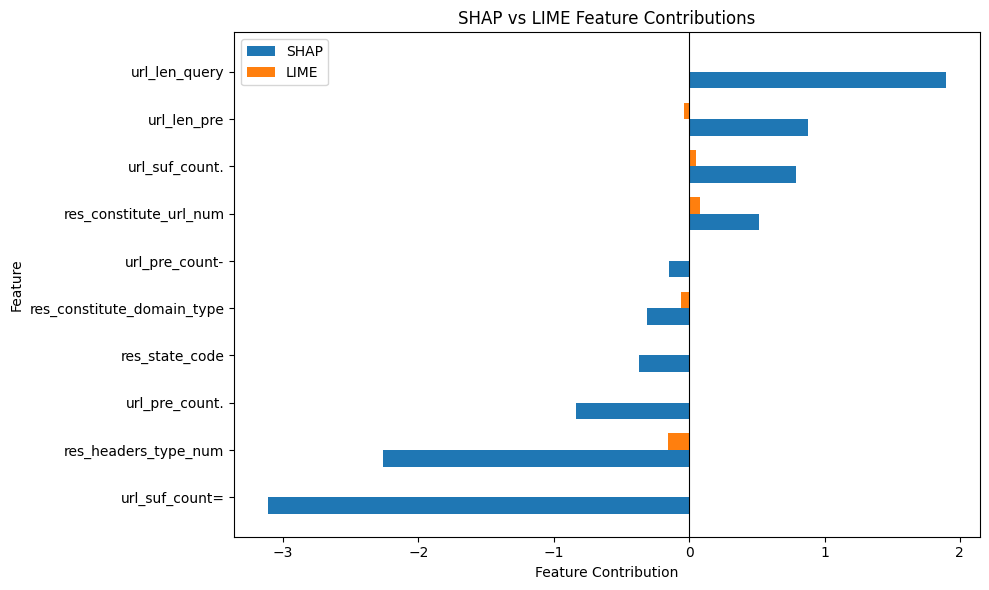

In [39]:
# =====================================================
# SHAP vs LIME FEATURE CONTRIBUTION
# =====================================================

plot_df = feature_comparison.copy()

plot_df = plot_df.head(10)

plot_df = plot_df.sort_values("SHAP")

plt.figure(figsize=(10, 6))

y = np.arange(len(plot_df))
height = 0.35

plt.barh(
    y - height / 2,
    plot_df["SHAP"],
    height,
    label="SHAP"
)

plt.barh(
    y + height / 2,
    plot_df["LIME"],
    height,
    label="LIME"
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.yticks(
    y,
    plot_df["Feature"]
)

plt.xlabel("Feature Contribution")

plt.ylabel("Feature")

plt.title(
    "SHAP vs LIME Feature Contributions"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "SHAP_vs_LIME_Contribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [40]:
# =====================================================
# Automatic Interpretation of SHAP-LIME Agreement
# =====================================================

print("\n" + "=" * 70)
print("INTERPRETATION OF SHAP-LIME AGREEMENT")
print("=" * 70)

# Retrieve values
top5_value = agreement_summary.loc[
    agreement_summary["Metric"] == "Top-10 Overlap", "Value"
].iloc[0]

spearman_value = agreement_summary.loc[
    agreement_summary["Metric"] == "Spearman Correlation", "Value"
].iloc[0]

cosine_value = agreement_summary.loc[
    agreement_summary["Metric"] == "Cosine Similarity", "Value"
].iloc[0]

sign_value = agreement_summary.loc[
    agreement_summary["Metric"] == "Sign Agreement", "Value"
].iloc[0]


# -----------------------------------------------------
# 1. Top-k Feature Overlap
# -----------------------------------------------------

print("\n1. Top-10 Feature Overlap")
print(f"   Score: {top5_value:.3f}")

if top5_value == 0:
    print("   Meaning: SHAP and LIME have no common features")
    print("            among their top-10 most important features.")
elif top5_value < 0.5:
    print("   Meaning: SHAP and LIME have limited overlap")
    print("            among their top-10 important features.")
else:
    print("   Meaning: SHAP and LIME identify several common")
    print("            important features.")


# -----------------------------------------------------
# 2. Spearman Correlation
# -----------------------------------------------------

print("\n2. Spearman Correlation")
print(f"   Score: {spearman_value:.3f}")

if abs(spearman_value) < 0.2:
    print("   Meaning: Very weak agreement in the ranking of")
    print("            features produced by SHAP and LIME.")
elif abs(spearman_value) < 0.5:
    print("   Meaning: Weak-to-moderate agreement in feature ranking.")
elif abs(spearman_value) < 0.8:
    print("   Meaning: Moderate-to-strong agreement in feature ranking.")
else:
    print("   Meaning: Strong agreement in feature ranking.")


# -----------------------------------------------------
# 3. Cosine Similarity
# -----------------------------------------------------

print("\n3. Cosine Similarity")
print(f"   Score: {cosine_value:.3f}")

if cosine_value < 0.2:
    print("   Meaning: Very low similarity between the SHAP")
    print("            and LIME importance profiles.")
elif cosine_value < 0.5:
    print("   Meaning: Moderate similarity between the")
    print("            SHAP and LIME importance profiles.")
else:
    print("   Meaning: High similarity between the SHAP")
    print("            and LIME importance profiles.")


# -----------------------------------------------------
# 4. Sign Agreement
# -----------------------------------------------------

print("\n4. Sign Agreement")
print(f"   Score: {sign_value:.3f}")
print(f"   Meaning: SHAP and LIME agree on the direction of")
print(f"            feature influence for approximately "
      f"{sign_value * 100:.1f}% of the evaluated features.")


# -----------------------------------------------------
# Overall Interpretation
# -----------------------------------------------------

print("\n" + "-" * 70)
print("OVERALL INTERPRETATION")
print("-" * 70)

if (
    top5_value == 0
    and abs(spearman_value) < 0.2
    and cosine_value < 0.2
):
    print(
        "SHAP and LIME show low explanation agreement for this "
        "user-defined URL. They identify different important "
        "features and produce substantially different feature "
        "importance rankings."
    )

elif (
    top5_value < 0.5
    and abs(spearman_value) < 0.5
    and cosine_value < 0.5
):
    print(
        "SHAP and LIME show limited agreement for this "
        "user-defined URL. Some differences exist in the "
        "features identified and their importance rankings."
    )

else:
    print(
        "SHAP and LIME show relatively good agreement for this "
        "user-defined URL, with similar feature importance "
        "patterns and rankings."
    )

print(
    "The agreement analysis compares two different XAI methods "
    "for the same URL prediction. SHAP and LIME may produce "
    "different explanations because they use different "
    "explanation mechanisms. Therefore, a low agreement score "
    "should be interpreted as low cross-explainer consistency "
    "rather than automatically indicating that either explanation "
    "is incorrect."
)

print("=" * 70)


INTERPRETATION OF SHAP-LIME AGREEMENT

1. Top-10 Feature Overlap
   Score: 0.500
   Meaning: SHAP and LIME identify several common
            important features.

2. Spearman Correlation
   Score: 0.259
   Meaning: Weak-to-moderate agreement in feature ranking.

3. Cosine Similarity
   Score: 0.218
   Meaning: Moderate similarity between the
            SHAP and LIME importance profiles.

4. Sign Agreement
   Score: 0.267
   Meaning: SHAP and LIME agree on the direction of
            feature influence for approximately 26.7% of the evaluated features.

----------------------------------------------------------------------
OVERALL INTERPRETATION
----------------------------------------------------------------------
SHAP and LIME show relatively good agreement for this user-defined URL, with similar feature importance patterns and rankings.
The agreement analysis compares two different XAI methods for the same URL prediction. SHAP and LIME may produce different explanations because th

In [41]:
import numpy as np
import pandas as pd
import shap
from urllib.parse import urlparse, urlunparse, parse_qs, urlencode
from sklearn.metrics.pairwise import cosine_similarity

# =====================================================
# SHAP explainer
# =====================================================

base_model = xgb_isotonic.calibrated_classifiers_[0].estimator
explainer = shap.TreeExplainer(base_model)

# =====================================================
# Prepare feature vector
# =====================================================

def prepare_input_features(url, training_features):

    features = extract_features(url)

    X = pd.DataFrame([features])

    remove_cols = [
        "url_len_suf",
        "url_pre_http_count",
        "url_pre_count/",
        "url_pre_count%",
        "url_pre_count=",
        "url_pre_count@"
    ]

    X = X.drop(
        columns=[c for c in remove_cols if c in X.columns],
        errors="ignore"
    )

    X = X.reindex(
        columns=training_features,
        fill_value=0
    )

    return X

# =====================================================
# Generate 10 realistic URL perturbations
# =====================================================

def generate_url_perturbations(url):

    parsed = urlparse(url)
    perturbations = []

    # 1. Add query parameter
    q = parse_qs(parsed.query)
    q["id"] = ["123"]
    perturbations.append(urlunparse(parsed._replace(query=urlencode(q, doseq=True))))

    # 2. Modify query value
    q2 = parse_qs(parsed.query)
    if len(q2) > 0:
        key = list(q2.keys())[0]
        q2[key] = [q2[key][0] + "123"]
    else:
        q2["q"] = ["test123"]
    perturbations.append(urlunparse(parsed._replace(query=urlencode(q2, doseq=True))))

    # 3. Add path component
    perturbations.append(
        urlunparse(parsed._replace(path=parsed.path.rstrip("/") + "/results"))
    )

    # 4. Add numeric token
    perturbations.append(
        urlunparse(parsed._replace(path=parsed.path.rstrip("/") + "2026"))
    )

    # 5. Toggle trailing slash
    if parsed.path.endswith("/"):
        new_path = parsed.path.rstrip("/")
    else:
        new_path = parsed.path + "/"
    perturbations.append(urlunparse(parsed._replace(path=new_path)))

    # 6. Add fragment
    perturbations.append(urlunparse(parsed._replace(fragment="home")))

    # 7. Add second query parameter
    q3 = parse_qs(parsed.query)
    q3["ref"] = ["abc"]
    perturbations.append(urlunparse(parsed._replace(query=urlencode(q3, doseq=True))))

    # 8. Extend path
    perturbations.append(
        urlunparse(parsed._replace(path=parsed.path.rstrip("/") + "/page"))
    )

    # 9. Add page parameter
    q4 = parse_qs(parsed.query)
    q4["page"] = ["1"]
    perturbations.append(urlunparse(parsed._replace(query=urlencode(q4, doseq=True))))

    # 10. Add tracking parameter
    q5 = parse_qs(parsed.query)
    q5["utm"] = ["campaign"]
    perturbations.append(urlunparse(parsed._replace(query=urlencode(q5, doseq=True))))

    return perturbations[:10]

# =====================================================
# Explanation stability analysis
# =====================================================

X_input = prepare_input_features(url, X_train.columns)

original_shap = explainer.shap_values(X_input)
if isinstance(original_shap, list):
    original_shap = original_shap[1]
original_shap = np.array(original_shap).flatten()

perturbed_urls = generate_url_perturbations(url)

stability_scores = []

print("=" * 60)
print("EXPLANATION STABILITY ANALYSIS")
print("=" * 60)

print("\\nNumber of perturbations:", len(perturbed_urls))
print("\\nIndividual Stability Scores:")

for i, p_url in enumerate(perturbed_urls, start=1):

    X_perturbed = prepare_input_features(
        p_url,
        X_train.columns
    )

    perturbed_shap = explainer.shap_values(X_perturbed)

    if isinstance(perturbed_shap, list):
        perturbed_shap = perturbed_shap[1]

    perturbed_shap = np.array(perturbed_shap).flatten()

    similarity = cosine_similarity(
        original_shap.reshape(1,-1),
        perturbed_shap.reshape(1,-1)
    )[0,0]

    stability_scores.append(similarity)

    print(f"Perturbation {i}: {similarity:.4f}")

average_stability = np.mean(stability_scores)

print("\\nAverage Explanation Stability Score:")
print(f"{average_stability:.4f}")

print("\\nInterpretation:")

if average_stability >= 0.90:
    print("Explanation is highly stable.")
elif average_stability >= 0.70:
    print("Explanation is moderately stable.")
elif average_stability >= 0.50:
    print("Explanation has moderate stability.")
else:
    print("Explanation has low stability.")

EXPLANATION STABILITY ANALYSIS
\nNumber of perturbations: 10
\nIndividual Stability Scores:
Perturbation 1: 0.9940
Perturbation 2: 0.9939
Perturbation 3: 1.0000
Perturbation 4: 0.9991
Perturbation 5: 0.6195
Perturbation 6: 0.9964
Perturbation 7: 0.9940
Perturbation 8: 1.0000
Perturbation 9: 0.9940
Perturbation 10: 0.9984
\nAverage Explanation Stability Score:
0.9589
\nInterpretation:
Explanation is highly stable.
